# Buổi 9: Học sâu

Cài đặt thư viện tensorflow
```bash
pip install tensorflow
```

## 1. Khai báo thư viện 

In [29]:
import numpy as np
from tensorflow import keras    # thư viện keras cho deep learning
import matplotlib.pyplot as plt # thư viện vẽ đồ thị
import time

## 2. Chuẩn bị dữ liệu

In [30]:
# tải dataset mnist từ thư viện dataset chuẩn trong keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## 3. Hiển thị dữ liệu

In [31]:
# Thông tin tập train
print(f'Train: n={len(x_train)}') 
print(f'+ x_train: {x_train.shape}, range = [{np.min(x_train)}, {np.max(x_train)}]') # shape + miền trị
print(f'+ y_train: {y_train.shape}, values= {np.unique(y_train)}') # shape + các giá trị output

# Thông tin tập test
print(f'Train: n={len(x_test)}') 
print(f'+ x_train: {x_test.shape}, range = [{np.min(x_test)}, {np.max(x_test)}]') # shape + miền trị
print(f'+ y_train: {y_test.shape}, values= {np.unique(y_test)}') # shape + các giá trị output

Train: n=60000
+ x_train: (60000, 28, 28), range = [0, 255]
+ y_train: (60000,), values= [0 1 2 3 4 5 6 7 8 9]
Train: n=10000
+ x_train: (10000, 28, 28), range = [0, 255]
+ y_train: (10000,), values= [0 1 2 3 4 5 6 7 8 9]


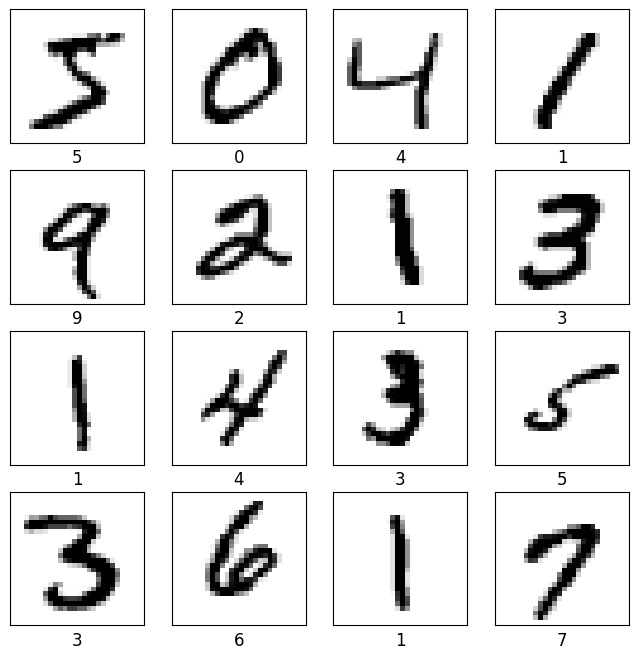

In [32]:
# Hiển thị dữ liệu train
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_train[i]}', fontsize = 12)
plt.show()

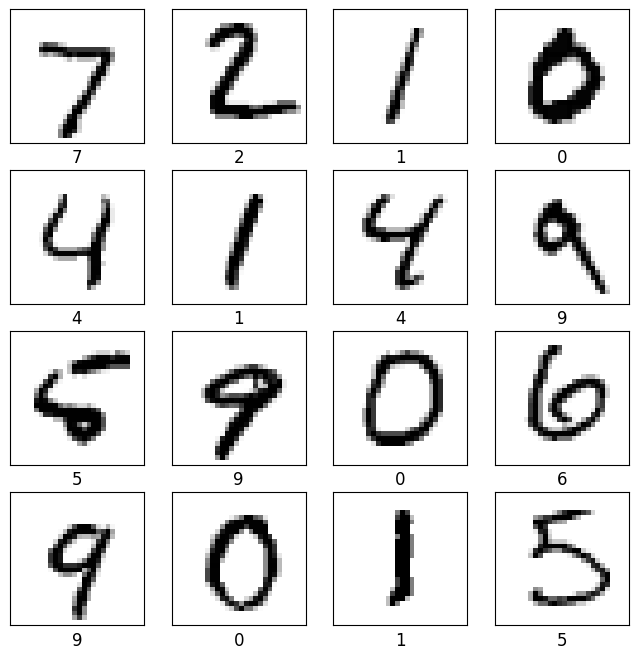

In [33]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_test[i]}', fontsize = 12)
plt.show()

## 4. Tiền xử lý dữ liệu

In [34]:
# Biến đổi ảnh về miền trị [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [35]:
# Mở rộng shape tại chiều cuối cùng (n_images,28,28) --> (n_images, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [36]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [37]:
# Chuyển đổi y_train, y_test sang dạng one-hot
num_classes = 10 # phân lớp 10 ký tự số (từ 0 đến 9)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [38]:
# dạng one-hot
y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [39]:
# dùng np.argmax để tìm vị trí có giá trị xác suất lớn nhất (đưa về label)
np.argmax(y_train[0:10], axis = 1)

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

## 5. Xây dựng Model

In [40]:
# xóa các lưu trữ 
keras.backend.clear_session() 

# xây dựng model
input_shape = (28, 28, 1)

# input
input_ = keras.Input(shape=input_shape)

# các blocks convolution để lấy features
# block 1 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(input_)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
# block 2 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# classification layers (gồm các dense layer, dropout)
x = keras.layers.Flatten()(x) # Đưa shape của x về dạng phẳng. Ví dụ: (28, 28, 1) --> (28x28x1, )
x = keras.layers.Dropout(0.5)(x) # Loại ngẫu nhiên 50% kết nối trong quá trình huấn luyện - tăng tính tổng quát hóa
output_ = keras.layers.Dense(num_classes, activation="softmax")(x) # kết xuất ra 10 classes dữ liệu dạng xác suất

model = keras.Model(inputs=input_, outputs=output_) # đưa vào model

model.summary() # hiển thị thông tin model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Huấn luyện Model

In [41]:
# khai báo learning rate, loss function, và model metric
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=["accuracy"])

batch_size = 128
epochs     = 15

starting_time = time.time()
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('> training time is %.4f minutes' % ((time.time() - starting_time)/60))

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9395 - loss: 0.1891 - val_accuracy: 0.9838 - val_loss: 0.0541
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9734 - loss: 0.0859 - val_accuracy: 0.9882 - val_loss: 0.0384
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9770 - loss: 0.0752 - val_accuracy: 0.9902 - val_loss: 0.0344
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9784 - loss: 0.0698 - val_accuracy: 0.9882 - val_loss: 0.0375
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9790 - loss: 0.0683 - val_accuracy: 0.9907 - val_loss: 0.0377
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9791 - loss: 0.0690 - val_accuracy: 0.9892 - val_loss: 0.0391
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9802 - loss: 0.0636 - val_accuracy: 0.9900 - val_loss: 0.0337
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9811 - loss: 0.0602 - val_accura

In [42]:
# list all data in history
print(model.history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


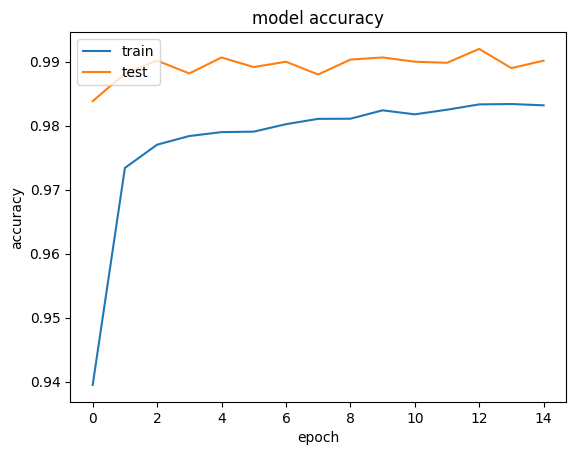

In [43]:
# summarize history for accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

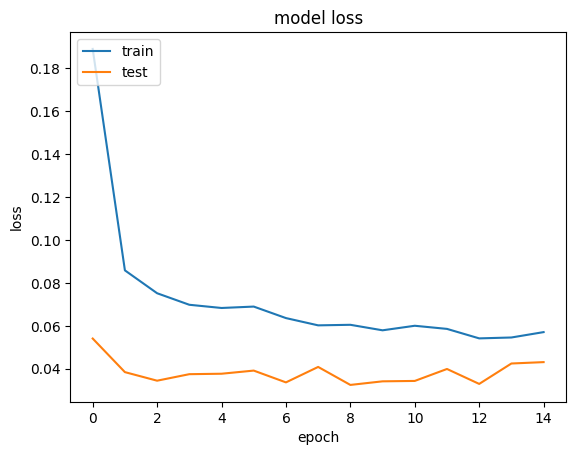

In [44]:
# summarize history for loss
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 7. Lượng giá Model

In [45]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.03709666058421135
Test accuracy: 0.9891999959945679


In [46]:
y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis = 1)
y_gt_label = np.argmax(y_test, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [47]:
# Các vị trí bị sai
false_pos = np.where(y_pred_label != y_gt_label)[0]
print(f'False Cases: {len(false_pos)} / {len(y_gt_label)}\n{false_pos}')

False Cases: 108 / 10000
[ 259  340  625  726  882  947  956 1014 1033 1039 1044 1182 1226 1232
 1242 1247 1260 1299 1393 1414 1527 1530 1621 1681 1709 1722 1878 1901
 1941 2018 2035 2070 2118 2130 2135 2182 2266 2293 2329 2369 2387 2406
 2414 2454 2578 2654 2896 2921 2927 2939 2953 2995 3012 3073 3100 3289
 3422 3503 3520 3567 3727 3730 3772 3808 3821 3850 3869 3951 4078 4126
 4176 4224 4284 4500 4536 4571 4740 4761 4837 4886 4956 4978 5246 5265
 5676 5937 5955 6166 6560 6576 6597 6625 6651 6783 6847 8325 8332 8382
 8408 9009 9587 9620 9634 9642 9664 9679 9692 9729]


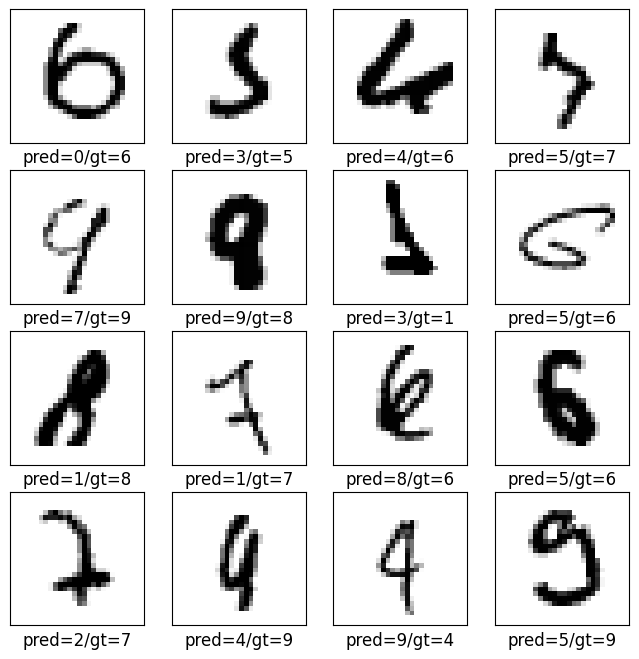

In [48]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    pos = false_pos[i]
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[pos], cmap=plt.cm.binary)
    plt.xlabel(f'pred={y_pred_label[pos]}/gt={y_gt_label[pos]}', fontsize = 12)
plt.show()

## Bài 2: Áp dụng trên tập Fashion-MNIST

In [49]:
# tải dataset Fashion-MNIST
(x_train_f, y_train_f), (x_test_f, y_test_f) = keras.datasets.fashion_mnist.load_data()

print(f'Train: n={len(x_train_f)}')
print(f'+ x_train_f: {x_train_f.shape}, range = [{np.min(x_train_f)}, {np.max(x_train_f)}]')
print(f'+ y_train_f: {y_train_f.shape}, values= {np.unique(y_train_f)}')

print(f'Test: n={len(x_test_f)}')
print(f'+ x_test_f: {x_test_f.shape}, range = [{np.min(x_test_f)}, {np.max(x_test_f)}]')
print(f'+ y_test_f: {y_test_f.shape}, values= {np.unique(y_test_f)}')

Train: n=60000
+ x_train_f: (60000, 28, 28), range = [0, 255]
+ y_train_f: (60000,), values= [0 1 2 3 4 5 6 7 8 9]
Test: n=10000
+ x_test_f: (10000, 28, 28), range = [0, 255]
+ y_test_f: (10000,), values= [0 1 2 3 4 5 6 7 8 9]


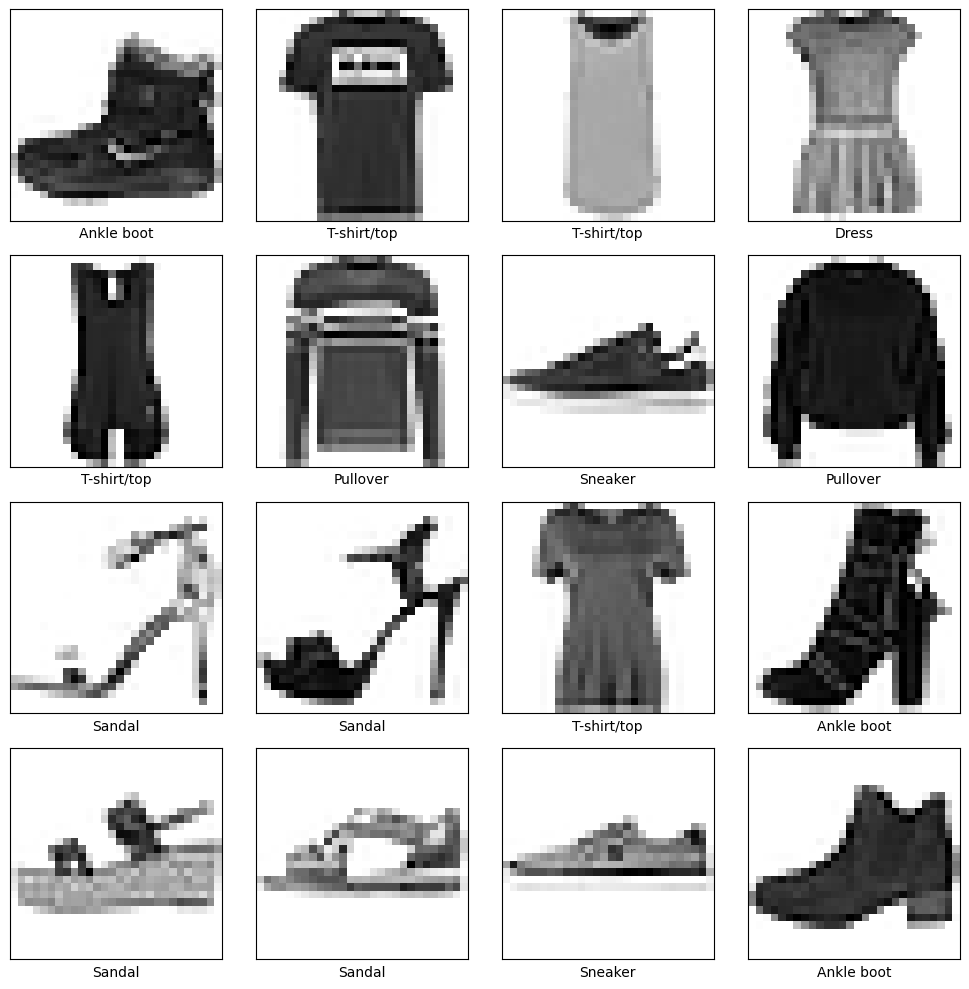

In [50]:
# tên lớp của Fashion-MNIST
fashion_labels = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
 ]

# hiển thị một số ảnh mẫu
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train_f[i], cmap=plt.cm.binary)
    plt.xlabel(fashion_labels[y_train_f[i]], fontsize=10)
plt.tight_layout()
plt.show()

In [51]:
# tiền xử lý dữ liệu Fashion-MNIST
x_train_f = x_train_f.astype("float32") / 255
x_test_f = x_test_f.astype("float32") / 255

x_train_f = np.expand_dims(x_train_f, -1)
x_test_f = np.expand_dims(x_test_f, -1)

y_train_f_oh = keras.utils.to_categorical(y_train_f, num_classes)
y_test_f_oh = keras.utils.to_categorical(y_test_f, num_classes)

print("x_train_f shape:", x_train_f.shape)
print("x_test_f shape:", x_test_f.shape)

x_train_f shape: (60000, 28, 28, 1)
x_test_f shape: (10000, 28, 28, 1)


In [52]:
# xây dựng model CNN cho Fashion-MNIST
keras.backend.clear_session()

input_f = keras.Input(shape=(28, 28, 1))
z = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(input_f)
z = keras.layers.MaxPooling2D(pool_size=(2, 2))(z)
z = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(z)
z = keras.layers.MaxPooling2D(pool_size=(2, 2))(z)
z = keras.layers.Flatten()(z)
z = keras.layers.Dropout(0.5)(z)
output_f = keras.layers.Dense(num_classes, activation="softmax")(z)

model_f = keras.Model(inputs=input_f, outputs=output_f)
model_f.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# huấn luyện model Fashion-MNIST
model_f.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
 )

batch_size_f = 128
epochs_f = 10

start_f = time.time()
history_f = model_f.fit(
    x_train_f, y_train_f_oh,
    batch_size=batch_size_f,
    epochs=epochs_f,
    validation_split=0.1
 )
print('> training time is %.4f minutes' % ((time.time() - start_f) / 60))

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7469 - loss: 0.7011 - val_accuracy: 0.8387 - val_loss: 0.4458
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8379 - loss: 0.4515 - val_accuracy: 0.8663 - val_loss: 0.3804
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8572 - loss: 0.4028 - val_accuracy: 0.8635 - val_loss: 0.3759
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8667 - loss: 0.3730 - val_accuracy: 0.8813 - val_loss: 0.3288
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8745 - loss: 0.3504 - val_accuracy: 0.8908 - val_loss: 0.3080
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8815 - loss: 0.3312 - val_accuracy: 0.8948 - val_loss: 0.2986
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8849 - loss: 0.3188 - val_accuracy: 0.8927 - val_loss: 0.2925
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8886 - loss: 0.3102 - val_accuracy: 0

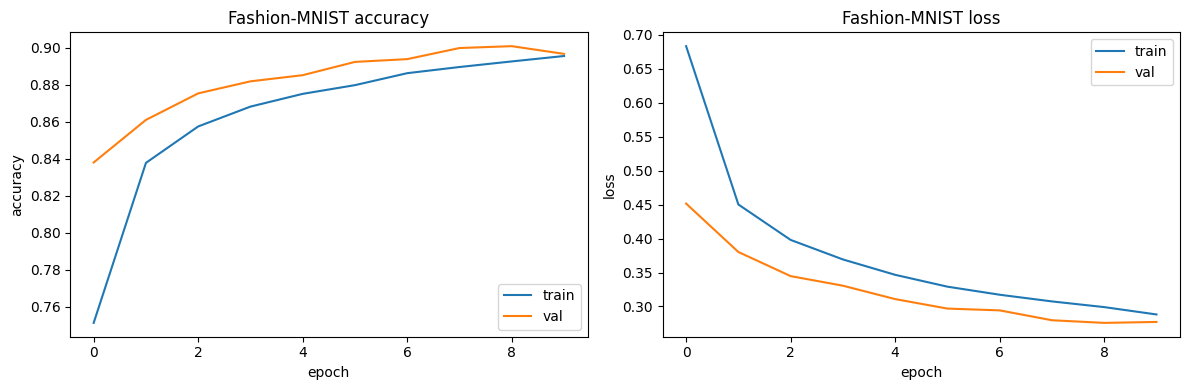

In [ ]:
# biểu đồ accuracy/loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_f.history['accuracy'])
plt.plot(history_f.history['val_accuracy'])
plt.title('Fashion-MNIST accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_f.history['loss'])
plt.plot(history_f.history['val_loss'])
plt.title('Fashion-MNIST loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# lượng giá trên tập test Fashion-MNIST
score_f = model_f.evaluate(x_test_f, y_test_f_oh, verbose=0)
print('Fashion Test loss:', score_f[0])
print('Fashion Test accuracy:', score_f[1])

y_pred_f = model_f.predict(x_test_f)
y_pred_f_label = np.argmax(y_pred_f, axis=1)

false_pos_f = np.where(y_pred_f_label != y_test_f)[0]
print(f'False Cases: {len(false_pos_f)} / {len(y_test_f)}')

Fashion Test loss: 0.2923756241798401
Fashion Test accuracy: 0.8938000202178955
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
False Cases: 1062 / 10000


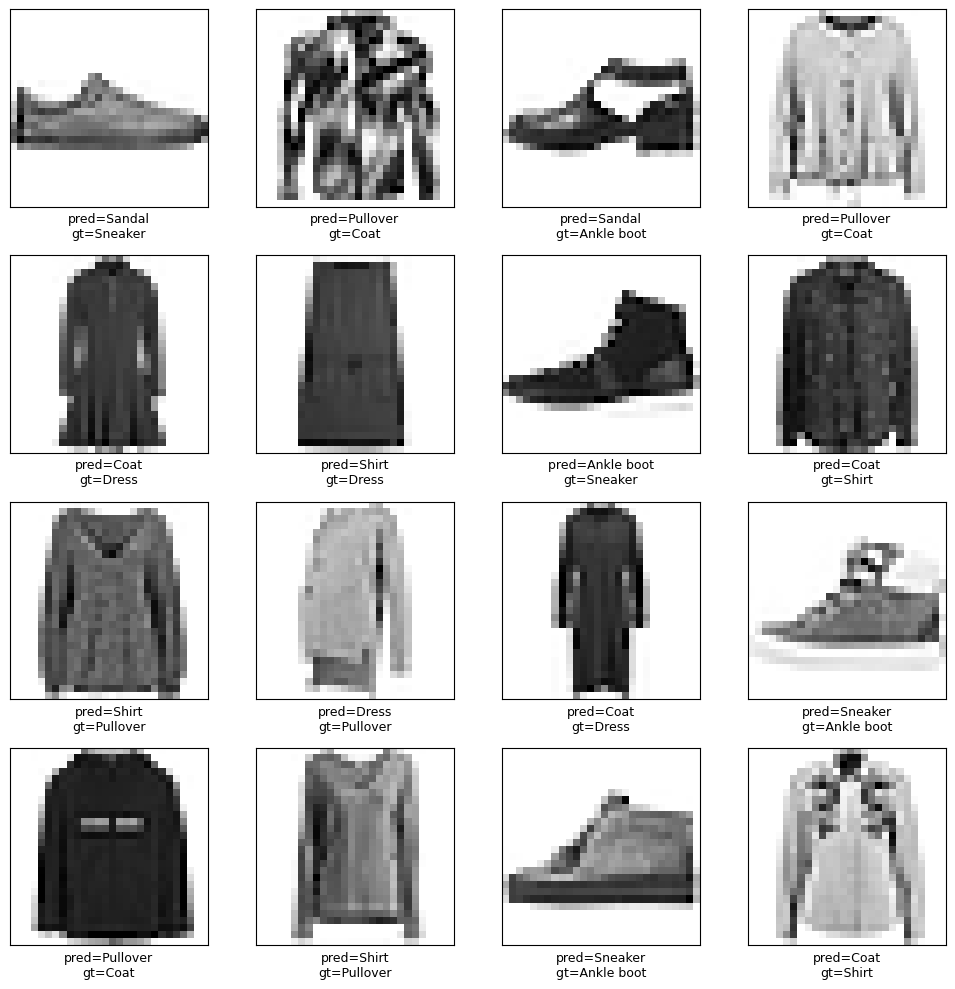

In [ ]:
# hiển thị một số mẫu dự đoán sai
plt.figure(figsize=(10, 10))
for i in range(min(16, len(false_pos_f))):
    pos = false_pos_f[i]
    plt.subplot(4, 4, i + 1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test_f[pos].squeeze(), cmap=plt.cm.binary)
    pred_name = fashion_labels[y_pred_f_label[pos]]
    gt_name = fashion_labels[y_test_f[pos]]
    plt.xlabel(f'pred={pred_name}\ngt={gt_name}', fontsize=9)
plt.tight_layout()
plt.show()

# Kết thúc